# Time-Dependent Correlation Functions in the Ising Model

## Goal of the notebook

This notebook estimates the complex real-time autocorrelation functions

$$
C_{SS}(t)=\langle\psi|S_0(t)S_0(0)|\psi\rangle,
\qquad S\in\{X,Y,Z\},
$$

with a Hadamard-test circuit. In the Heisenberg picture,

$$
S_0(t)=U^\dagger(t)S_0U(t),\qquad U(t)=e^{-iHt}.
$$

The simulated Hamiltonian is

$$
H=-h\sum_i Z_i-J\sum_{\langle i,j\rangle}X_iX_j,
$$

and $U(t)$ is approximated by a symmetric Trotter–Suzuki product formula. The notebook compares finite-shot estimates obtained from an ideal simulator with estimates produced by a simple gate-level depolarizing noise model.

### Learning objectives

1. Relate a two-branch ancilla interference experiment to a complex correlation function.
2. Understand why different final ancilla rotations recover the real and imaginary parts.
3. Distinguish Trotter error, shot noise, gate noise, and readout noise.
4. Interpret error bars and clean-versus-noisy comparisons correctly.
5. Identify useful zero-time and symmetry checks before trusting a full time series.


In [1]:
# Numerical arrays hold time grids, sampled estimators, and summary metrics.
import numpy as np
# Matplotlib is used for correlation-function plots with error bars.
import matplotlib.pyplot as plt
# QuantumCircuit represents the system register and the Hadamard-test ancilla.
from qiskit import QuantumCircuit
# Aer supplies shot-based simulation with an optional noise model.
from qiskit_aer import AerSimulator
# Transpilation maps the abstract circuit to simulator-supported instructions.
from qiskit.compiler import transpile
# These constructors define the simplified gate-level error channels.
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error

## Part 1 — System Representation and Helper Functions

The `System` class collects the spin count, interaction graph, coupling constants, state preparation, Trotterized evolution, and shot-based measurements.

For each Trotter step, the circuit implements

$$
e^{-iH_Z\Delta t/2}
e^{-iH_{XX}\Delta t}
e^{-iH_Z\Delta t/2}.
$$

Using Qiskit’s definitions $R_Z(\theta)=e^{-i\theta Z/2}$ and $R_{XX}(\theta)=e^{-i\theta X\otimes X/2}$ explains the angles `-h * dt` and `-2 * J * dt` in the circuit.

The measurement helpers rotate the requested Pauli basis into the computational basis and convert bit counts into estimates of Pauli-$Z$ eigenvalues. Reversing each count string with `k[::-1]` aligns the displayed Qiskit bit order with increasing qubit indices.

### Hadamard-test identity used below

Immediately before the final ancilla rotation, the two branches contain

$$
|a\rangle=U(t)|\psi\rangle,
\qquad
|b\rangle=O_2U(t)O_1|\psi\rangle.
$$

Their overlap is

$$
\langle a|b\rangle
=\langle\psi|U^\dagger(t)O_2U(t)O_1|\psi\rangle.
$$

Thus, with $O_1=O_2=S_0$, the circuit estimates $\langle S_0(t)S_0(0)\rangle$ without explicitly constructing $U^\dagger$.


In [6]:
def colorEdge(edges, e):
    """Color edges such that no two edges sharing a vertex have the same color.
    Args:
        edges: List of [vertex1, vertex2, color] for each edge
        e: Number of edges
    Returns:
        edges: Colored edge list
    Comment:
        coloring exposes potential parallelism in execution of 2-qubit gates, but does not itself guarantee a hardware schedule
        transpilation and backend constraints still matter
    """
    assert(e>0)
    # Add a third mutable field that will hold the color; -1 means unassigned.
    edge_list = [[q, r, -1] for (q, r) in edges]
    # Process one edge at a time and search for a nonconflicting integer color.
    i = 0
    color = 1
    while(i < e):
        edge_list[i][2] = color
        flag = False
        # Compare the candidate edge with every other edge for a shared endpoint.
        for j in range(e):
            if (j == i):
                continue
            if ((edge_list[i][0] == edge_list[j][0])or
                (edge_list[i][1] == edge_list[j][0]) or
                (edge_list[i][0] == edge_list[j][1]) or
                    (edge_list[i][1] == edge_list[j][1])):
                if (edge_list[i][2] == edge_list[j][2]):
                    # Retry this edge with the next candidate color.
                    color += 1
                    flag = True
                    break
        if (flag == True):
            continue
 
        color = 1
        i += 1
 
    # Scan the assigned labels to report the number of color classes.
    maxColor = -1
    for i in range(e):
        maxColor = max(maxColor, edge_list[i][2])
    print(str(maxColor)+" colors needed for edge coloring")
    for i in range(e):
        print("edge between v("+str(edge_list[i][0])+") and v("+ str(edge_list[i][1])+") has color "+str(edge_list[i][2]))

    return edge_list

class System:
    def __init__(self, n=1, e=None, J=1.0, h=1.0, verbose=False):
        # Collect all model parameters and scheduled edge groups in one dictionary.
        self.args = {}
        self.args['n_spin'] = n
        self.args['edges'] = e if e is not None else []
        self.args['J'] = J
        self.args['h'] = h

        # Add an initially unassigned color field to every interaction edge.
        edges = self.args['edges']
        nedge = len(edges)
        edges = colorEdge(edges, nedge)
        color = set([edges[k][2] for k in range(nedge)])
        # Group nonoverlapping edges by color for potential parallel execution.
        edges = {c: [(q, r) for (q, r, cqr) in edges if cqr == c] for c in color}
        if(verbose):
            for c in color:
                print("color ", c, " edges ", edges[c])
        self.args['edges'] = edges
        self.args['color'] = color

    def prepare_bts(self, initial_bts=None, barrier=False):
        n = self.args['n_spin']
        # Qiskit starts the system register in |0>^n.
        qc = QuantumCircuit(n)
        if(initial_bts is not None):
            for i, xi in enumerate(initial_bts):
                if(xi == 1):
                    qc.x(i)
        if(barrier):
            qc.barrier()
        return qc

    def make_time_evolution_circuit(self, dt=0.0, n_trotter=1, barrier=False):
        n = self.args['n_spin']
        h = self.args['h']
        J = self.args['J']
        # Qiskit starts the system register in |0>^n.
        qc = QuantumCircuit(n)
        color = self.args['color']
        edges = self.args['edges']
        # Repeat a field-half / interaction-full / field-half product-formula step.
        for i_trotter in range(n_trotter):
            for q in range(n):
                # One RZ(-h*dt) layer represents a half step under -h*Z.
                qc.rz(-dt * h, q)
            if(barrier):
                qc.barrier()
            for c in color:
                for q, r in edges[c]:
                    # RXX(-2*J*dt) realizes the full short-time -J*X⊗X interaction.
                    qc.rxx(-2 * J * dt, q, r)
            if(barrier):
                qc.barrier()
            for q in range(n):
                # One RZ(-h*dt) layer represents a half step under -h*Z.
                qc.rz(-dt * h, q)
            if(barrier):
                qc.barrier()
        return qc

    def measure_qasm(self, qc, bases, shots, noise_model=None, verbose=False):
        """Measure in multiple bases with optional noise model."""
        assert(shots>1)
        # The MPS method avoids explicitly storing a dense 2**n statevector when possible.
        simul = AerSimulator(method='matrix_product_state')
        circuits = {}
        results = {}
        for basis in bases:
            if(verbose):
                print('basis ', basis)
            # Add basis changes and measurements to a copy of the input circuit.
            qc_basis = qc.copy()
            if(basis == 'x'):
                for i in range(qc_basis.num_qubits):
                    qc_basis.h(i)
            elif(basis == 'y'):
                for i in range(qc_basis.num_qubits):
                    # S† followed by H maps a Y-basis measurement to the Z basis.
                    qc_basis.sdg(i)
                    qc_basis.h(i)
            # Append one classical bit per qubit and measure the complete register.
            qc_basis.measure_all()
            circuits[basis] = qc_basis
            if(verbose):
                print(qc_basis.draw())
            if noise_model is not None:
                results[basis] = simul.run(transpile(qc_basis, simul), shots=shots, noise_model=noise_model).result().get_counts(0)
            else:
                results[basis] = simul.run(transpile(qc_basis, simul), shots=shots).result().get_counts(0)
            if(verbose):
                print(results[basis])
        return circuits, results

    def measure_density_qasm(self, qc, shots, basis='z', noise_model=None, verbose=False):
        """Measure expectation values and standard error of that mean in given basis."""
        n = qc.num_qubits
        bases = [basis]
        circuits, results = self.measure_qasm(qc, bases, shots, noise_model, verbose)
        Z1 = np.zeros(n, dtype=float)
        Z2 = np.zeros(n, dtype=float)
        for k in results[basis].keys():
            v = results[basis][k]
            # Reverse Qiskit's displayed count string so array index i matches qubit i.
            x = np.asarray([1 - 2 * int(x) for x in k[::-1]])
            Z1 += v * x
            Z2 += v * x**2
        Z1, Z2 = Z1 / shots, Z2 / shots
        # For ±1 samples this is the estimated standard error of the sample mean.
        Z2 = np.sqrt(np.abs(Z2 - Z1**2) / (shots - 1))
        return Z1, Z2, circuits, results

def make_hadamard_circuit(psi, qct, op1, op2, q1, q2):
    """Create Hadamard test circuits for measuring correlation functions."""

    if(op1!='X' and op1!='Y' and op1!='Z'): exit()
    if(op2!='X' and op2!='Y' and op2!='Z'): exit()
    if(q1<0 or q1>psi.num_qubits-1): exit()
    if(q2<0 or q2>psi.num_qubits-1): exit()
    if(psi.num_qubits!=qct.num_qubits): exit()

    N = psi.num_qubits
    qc = QuantumCircuit(N + 1)
    # Append the ancilla after all N system qubits.
    ancilla = N
    qc = qc.compose(psi, [x for x in range(N + 1) if x != ancilla])
    qc.barrier()
    # Create two coherent branches whose overlap encodes the correlator.
    qc.h(ancilla)
    qc.barrier()
    if(op1 == 'X'):
        qc.cx(ancilla, q1)
    if(op1 == 'Y'):
        qc.cy(ancilla, q1)
    if(op1 == 'Z'):
        qc.cz(ancilla, q1)
    qc.barrier()
    # Apply U(t) only to the system register; the ancilla is excluded.
    qc = qc.compose(qct, [x for x in range(N + 1) if x != ancilla])
    qc.barrier()
    if(op2 == 'X'):
        qc.cx(ancilla, q2)
    if(op2 == 'Y'):
        qc.cy(ancilla, q2)
    if(op2 == 'Z'):
        qc.cz(ancilla, q2)
    qc.barrier()
    qcx = qc.copy()
    # Final H measures the ancilla X expectation, yielding the real part.
    qcx.h(ancilla)
    qcy = qc.copy()
    # S† and H map the ancilla Y expectation, yielding the imaginary part.
    qcy.sdg(ancilla)
    qcy.h(ancilla)
    return qcx, qcy, ancilla

## Part 2 — Initialize the Spin Chain

The example uses three spins with open boundary conditions and edges $(0,1)$ and $(1,2)$. Both energy scales are set to one, so the dynamics depend on the dimensionless time $t$ in units where $\hbar=1$.

No bit string is passed to `prepare_bts`, so the initial state is the fully $Z$-polarized product state $|000\rangle$. This simple state makes several zero-time checks immediate and provides a clear starting point for an interaction quench.


In [7]:
# Define a simple 3-spin chain
# Three spins keep circuit drawings and sampled simulations manageable.
n = 3
# Open-chain connectivity: only adjacent sites interact.
e = [(0, 1), (1, 2)]
J = 1.0
h = 1.0
# Construct the system and precompute its edge-color groups.
S = System(n, e, J, h)

print(f"System initialized: {n} spins, {len(e)} edges")
print(f"Coupling strength J = {J}, Magnetic field h = {h}")

2 colors needed for edge coloring
edge between v(0) and v(1) has color 1
edge between v(1) and v(2) has color 2
System initialized: 3 spins, 2 edges
Coupling strength J = 1.0, Magnetic field h = 1.0


## Part 3 — Correlations with Statistical Noise Only

In this section, “clean” means that no explicit device-noise model is supplied. The circuit is still sampled with a finite number of shots, so its estimates fluctuate statistically and carry nonzero error bars.

The calculation also retains deterministic product-formula error because the time-evolution circuit uses a finite Trotter step. It is therefore useful to keep the following error sources separate:

- **Trotter error:** approximation of the exact unitary by a finite product formula;
- **shot noise:** uncertainty from a finite number of circuit repetitions;
- **gate/readout noise:** absent from this section and introduced later.


### Example Hadamard-Test Circuit

Before generating the complete time series, the notebook prints a circuit with two Trotter steps. The system register has three qubits and an additional ancilla is appended at index three.

The ancilla is placed in a coherent superposition, so its $|0\rangle$ branch undergoes $U(t)$ while its $|1\rangle$ branch undergoes $O_2U(t)O_1$. Interference between these branches reveals their complex overlap.

For the real-part circuit, a final Hadamard maps the ancilla $X$ expectation to a computational-basis $Z$ measurement. For the imaginary-part circuit, `Sdg` followed by a Hadamard maps the ancilla $Y$ expectation instead.

Barriers are used only to make the conceptual stages visible in the drawing. They are not physical operations.


Hadamard Test Circuit for X-X Correlation (with 2 Trotter steps)
Total qubits: 4 (qubit 3 is the ancilla)

Circuit (Real part - for imaginary part use qcy):


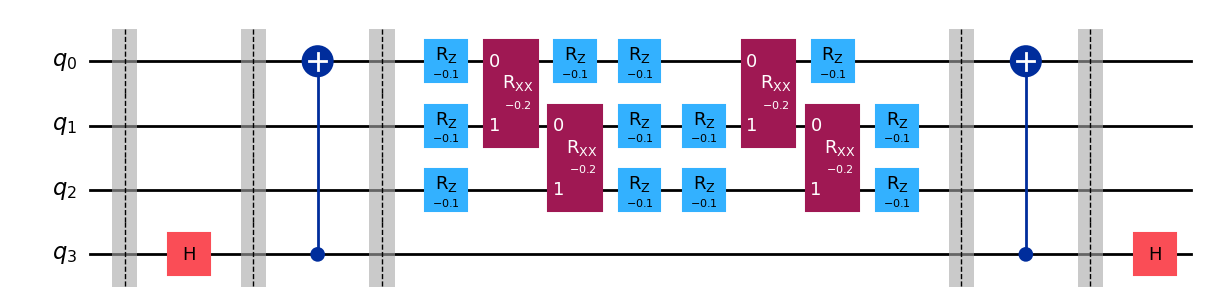

In [8]:
# Visualize an example Hadamard test circuit with 2 Trotter steps
# This helps understand the structure before running full calculations

# Use a shallow example so the Hadamard-test structure remains readable.
n_steps = 2
dt = 0.1
# With no bit string supplied, the initial system state is |000>.
qc0 = S.prepare_bts()
qct = S.make_time_evolution_circuit(dt=dt, n_trotter=n_steps)
# Build separate readout circuits for Re[C_XX] and Im[C_XX].
qcx, qcy, ancilla = make_hadamard_circuit(qc0, qct, 'X', 'X', 0, 0)

print(f"Hadamard Test Circuit for X-X Correlation (with {n_steps} Trotter steps)")
print(f"Total qubits: {qcx.num_qubits} (qubit {ancilla} is the ancilla)")
print(f"\nCircuit (Real part - for imaginary part use qcy):")
#print(qcx.draw())
qcx.draw('mpl')

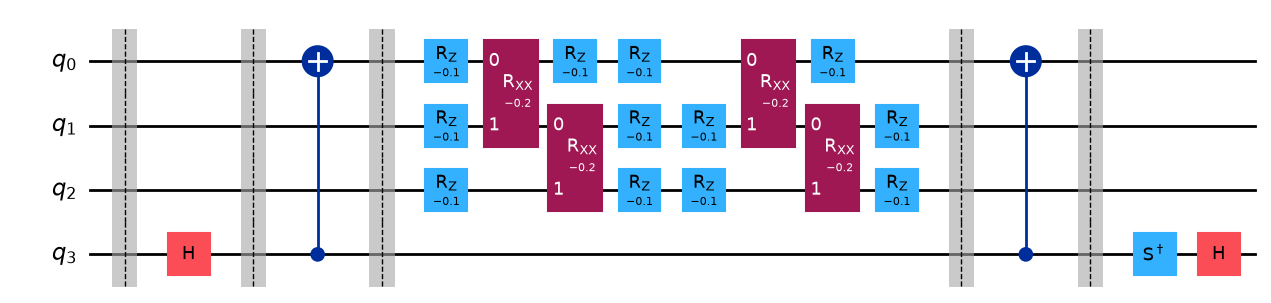

In [5]:
qcy.draw('mpl')

In [9]:
# Time parameters
n_step = 60
#tmax = 6.0
dt = 0.1
shots = 1000
t_vec = [x*dt for x in range(n_step+1)]
#np.arange(0, tmax, dt)

# Store results for all bases
correlations_clean = {}
# Evaluate same-site, same-Pauli autocorrelations at site 0.
operators = [('X', 'X'), ('Y', 'Y'), ('Z', 'Z')]

for op1, op2 in operators:
    print(f"\nComputing {op1}-{op2} correlation (clean)...")
    correlations_clean[f'{op1}{op2}'] = {'Re': [], 'Im': [], 'Re_std': [], 'Im_std': []}
    
    for n_trotter,t in enumerate(t_vec): #in t_vec:
        qc0 = S.prepare_bts()
        # Convert each requested time to a whole number of Trotter repetitions.
        qct = S.make_time_evolution_circuit(dt=dt, n_trotter=int(t/dt))
        qcx, qcy, ancilla = make_hadamard_circuit(qc0, qct, op1, op2, 0, 0)
        
        # Real part
        # Ancilla Z after its final H estimates the correlator's real component.
        R_ave, R_std, _, _ = S.measure_density_qasm(qcx, shots, basis='z')
        correlations_clean[f'{op1}{op2}']['Re'].append(R_ave[ancilla])
        correlations_clean[f'{op1}{op2}']['Re_std'].append(R_std[ancilla])
        
        # Imaginary part
        # Ancilla Z after S† and H estimates the imaginary component.
        I_ave, I_std, _, _ = S.measure_density_qasm(qcy, shots, basis='z')
        correlations_clean[f'{op1}{op2}']['Im'].append(I_ave[ancilla])
        correlations_clean[f'{op1}{op2}']['Im_std'].append(I_std[ancilla])

print("\nClean shot computation completed!")


Computing X-X correlation (clean)...

Computing Y-Y correlation (clean)...

Computing Z-Z correlation (clean)...

Clean shot computation completed!


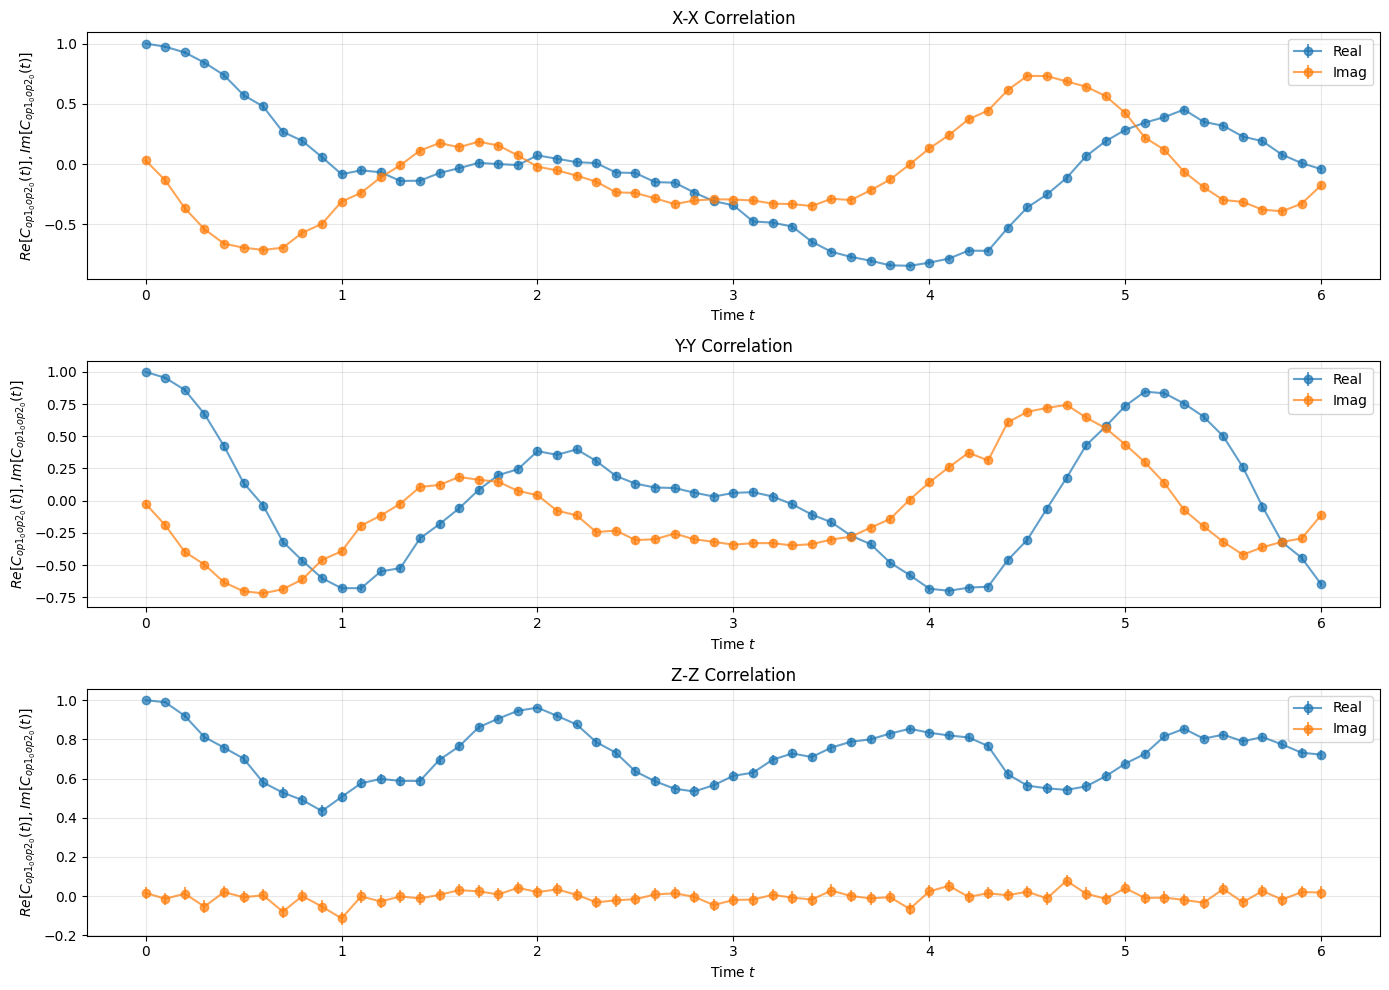

In [15]:
# Plot correlation functions

# Allocate one row per Pauli autocorrelation.
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, (op1, op2) in enumerate(operators):
    op_label = f'{op1}{op2}'
    
    # Real part
    # Plot the shot estimate together with its estimated standard error.
    axes[idx].errorbar(t_vec, correlations_clean[op_label]['Re'], 
                yerr=correlations_clean[op_label]['Re_std'], 
                label='Real', marker='o', linestyle='-', alpha=0.7)
    axes[idx].set_xlabel('Time $t$')
    #axes[idx].set_ylabel(f'$\\Re[C_{{{op1}_0{op2}_{0}}}(t)]$')
    #axes[idx].set_title(f'{op1}-{op2} Correlation: Real Part')
    #ax[idx].legend()
    #ax[idx].grid(True, alpha=0.3)
    
    # Imaginary part comparison
    axes[idx].errorbar(t_vec, correlations_clean[op_label]['Im'], 
                yerr=correlations_clean[op_label]['Im_std'], 
                label='Imag', marker='o', linestyle='-', alpha=0.7)
    axes[idx].set_xlabel('Time $t$')
    #axes[idx].set_ylabel(f'$\\Re[C_{{{op1}_0{op2}_{0}}}(t)]$')
    axes[idx].set_ylabel(r'$Re[C_{{{op1}_0{op2}_{0}}}(t)], Im[C_{{{op1}_0{op2}_{0}}}(t)]$')
    axes[idx].set_title(f'{op1}-{op2} Correlation')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 4 — Define a Gate-Level Noise Model

The intended model adds independent depolarizing errors after one- and two-qubit gates and attempts to include a measurement error. Depolarizing noise replaces the ideal state with an isotropically randomized component with a probability controlled by the specified error parameter.

This is a pedagogical effective model, not a full hardware model. It does not include gate durations, amplitude damping, dephasing times, crosstalk, leakage, coherent calibration errors, or qubit-dependent calibration data.

The names of the instructions to which errors are attached must match the instructions retained after transpilation. The readout channel also requires special care because a phase flip immediately before a computational-basis measurement cannot change the observed bit probabilities.


In [16]:
# Create a simple depolarizing noise model
# Start from an empty instruction-level Aer noise model.
noise_model = NoiseModel()

# Single-qubit error rate
p_1q = 0.001  # 0.1% per single-qubit gate
# Two-qubit error rate
p_2q = 0.01   # 1% per two-qubit gate

# Add errors to single-qubit gates
# Construct a one-qubit depolarizing channel with the chosen error parameter.
error_1q = depolarizing_error(p_1q, 1)
noise_model.add_all_qubit_quantum_error(error_1q, ['h', 'x', 'y', 'z', 'rz', 'sdg'])

# Add errors to two-qubit gates
# Two-qubit operations receive a stronger independent depolarizing channel.
error_2q = depolarizing_error(p_2q, 2)
noise_model.add_all_qubit_quantum_error(error_2q, ['cx', 'cy', 'cz', 'rxx'])

# Add measurement error
p_meas = 0.01  # 1% measurement error
# Readout noise, modeled by a bit flip
error_meas = pauli_error([('I', 1 - p_meas), ('X', p_meas)])
noise_model.add_all_qubit_quantum_error(error_meas, 'measure')

print(f"Noise model configured:")
print(f"  Single-qubit error rate: {p_1q*100}%")
print(f"  Two-qubit error rate: {p_2q*100}%")
print(f"  Measurement error rate: {p_meas*100}%")

Noise model configured:
  Single-qubit error rate: 0.1%
  Two-qubit error rate: 1.0%
  Measurement error rate: 1.0%


## Part 5 — Repeat the Correlation Calculation with Noise

The same Hadamard-test circuits, time grid, observables, and shot count are now simulated with the noise model. Keeping these high-level choices fixed makes the two datasets comparable.

Each circuit execution nevertheless uses a fresh random sample. Consequently, a pointwise clean-versus-noisy difference combines the systematic influence of the noise model with ordinary sampling fluctuations. Reproducible random seeds or repeated batches are useful when quantifying these contributions separately.


In [17]:
# Compute with noise
# Store noisy estimates separately so the clean data remain unchanged.
correlations_noisy = {}

for op1, op2 in operators:
    print(f"\nComputing {op1}-{op2} correlation (with noise)...")
    correlations_noisy[f'{op1}{op2}'] = {'Re': [], 'Im': [], 'Re_std': [], 'Im_std': []}
    
    for t in t_vec:
        qc0 = S.prepare_bts()
        qct = S.make_time_evolution_circuit(dt=dt, n_trotter=int(t/dt))
        # Rebuild the same logical observable circuit before applying simulator noise.
        qcx, qcy, ancilla = make_hadamard_circuit(qc0, qct, op1, op2, 0, 0)
        
        # Real part
        # Every gate execution is now subject to the configured matching error channel.
        R_ave, R_std, _, _ = S.measure_density_qasm(qcx, shots, basis='z', noise_model=noise_model)
        correlations_noisy[f'{op1}{op2}']['Re'].append(R_ave[ancilla])
        correlations_noisy[f'{op1}{op2}']['Re_std'].append(R_std[ancilla])
        
        # Imaginary part
        I_ave, I_std, _, _ = S.measure_density_qasm(qcy, shots, basis='z', noise_model=noise_model)
        correlations_noisy[f'{op1}{op2}']['Im'].append(I_ave[ancilla])
        correlations_noisy[f'{op1}{op2}']['Im_std'].append(I_std[ancilla])

print("\nNoisy shot computation completed!")


Computing X-X correlation (with noise)...

Computing Y-Y correlation (with noise)...

Computing Z-Z correlation (with noise)...

Noisy shot computation completed!


## Part 6 — Compare Clean and Noisy Results

Each row corresponds to one autocorrelation function ($XX$, $YY$, or $ZZ$). The left column displays the real part and the right column displays the imaginary part. Both ideal finite-shot estimates and noisy finite-shot estimates are shown with error bars.

The absolute value of a unitary Pauli correlation cannot exceed one. Values outside this interval beyond the expected statistical uncertainty should trigger a check of the estimator, indexing convention, or plotted data.

As circuit depth grows with time, a gate-local noise model generally produces a larger accumulated distortion. This trend should be interpreted together with the error bars rather than from individual pointwise differences alone.


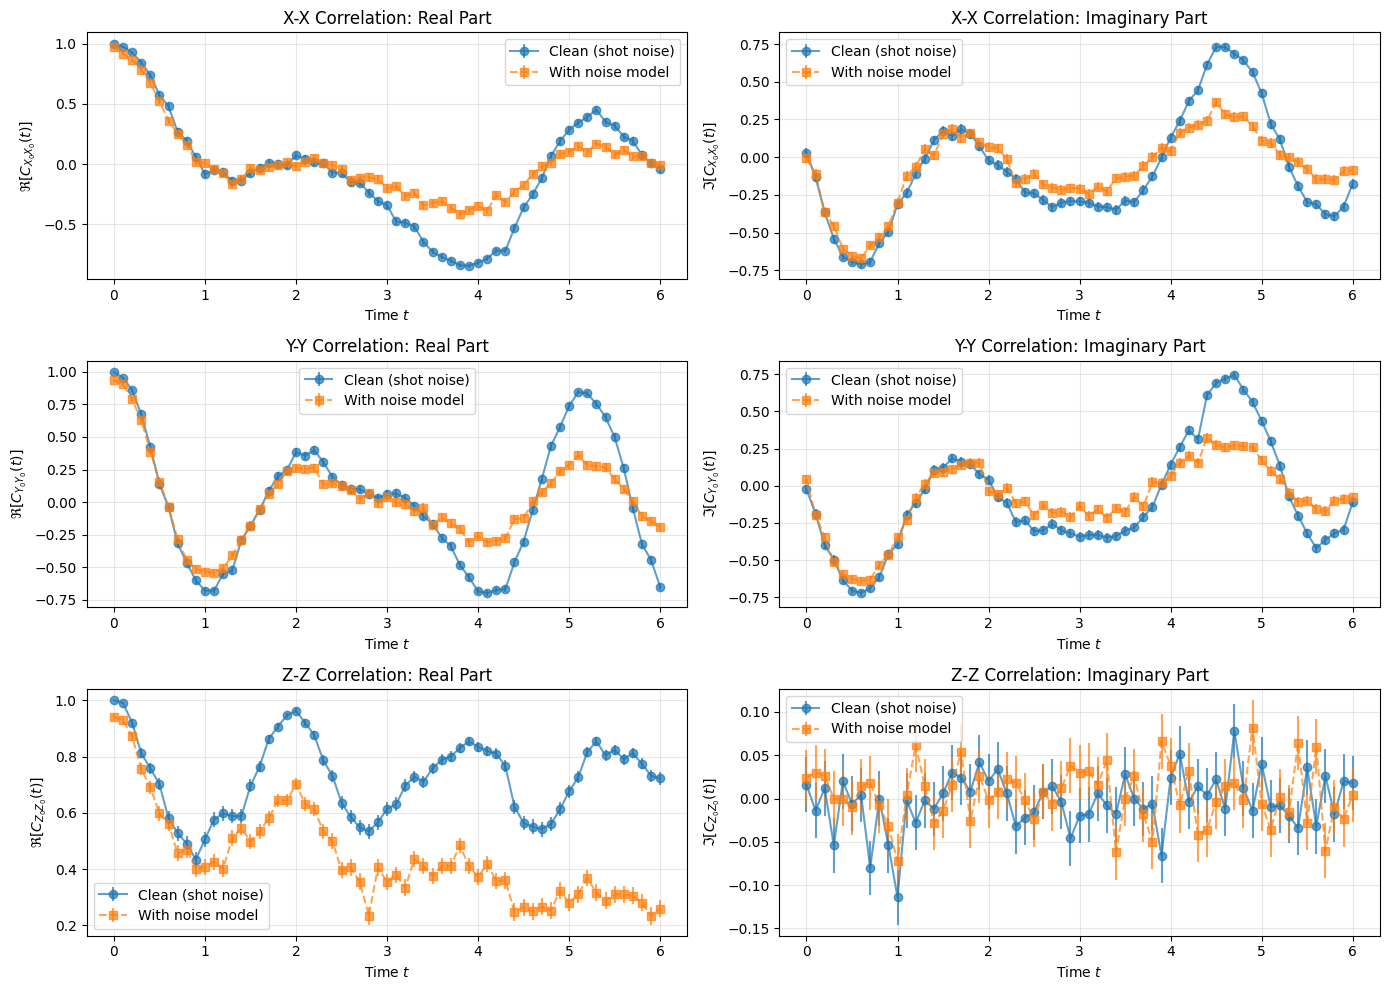

In [18]:
# Create comparison plots
# Rows select the Pauli operator; columns separate real and imaginary components.
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for idx, (op1, op2) in enumerate(operators):
    op_label = f'{op1}{op2}'
    
    # Real part comparison
    # Left column: compare real-part estimates.
    ax = axes[idx, 0]
    ax.errorbar(t_vec, correlations_clean[op_label]['Re'], 
                yerr=correlations_clean[op_label]['Re_std'], 
                label='Clean (shot noise)', marker='o', linestyle='-', alpha=0.7)
    ax.errorbar(t_vec, correlations_noisy[op_label]['Re'], 
                yerr=correlations_noisy[op_label]['Re_std'], 
                label='With noise model', marker='s', linestyle='--', alpha=0.7)
    ax.set_xlabel('Time $t$')
    ax.set_ylabel(f'$\\Re[C_{{{op1}_0{op2}_{0}}}(t)]$')
    ax.set_title(f'{op1}-{op2} Correlation: Real Part')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Imaginary part comparison
    # Right column: compare imaginary-part estimates.
    ax = axes[idx, 1]
    ax.errorbar(t_vec, correlations_clean[op_label]['Im'], 
                yerr=correlations_clean[op_label]['Im_std'], 
                label='Clean (shot noise)', marker='o', linestyle='-', alpha=0.7)
    ax.errorbar(t_vec, correlations_noisy[op_label]['Im'], 
                yerr=correlations_noisy[op_label]['Im_std'], 
                label='With noise model', marker='s', linestyle='--', alpha=0.7)
    ax.set_xlabel('Time $t$')
    ax.set_ylabel(f'$\\Im[C_{{{op1}_0{op2}_{0}}}(t)]$')
    ax.set_title(f'{op1}-{op2} Correlation: Imaginary Part')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 7 — Quantify the Apparent Noise Impact

The final code cell reports the mean absolute clean-versus-noisy difference for the real and imaginary components. An absolute metric is easy to interpret on the natural correlation scale $[-1,1]$.

Relative errors require more caution. When the clean signal is close to zero, division by that value can produce an arbitrarily large ratio even if the absolute discrepancy is small. A thresholded relative metric, a root-mean-square absolute error, or a comparison normalized by the full signal range is often more stable.

Because the two datasets contain independent finite-shot fluctuations, the reported differences should be described as **observed clean/noisy discrepancies**, not as a pure estimate of device-noise bias.


In [19]:
# Calculate noise-induced changes
print("Noise Impact Analysis")
print("=" * 60)

for op1, op2 in operators:
    op_label = f'{op1}{op2}'
    clean_re = np.array(correlations_clean[op_label]['Re'])
    noisy_re = np.array(correlations_noisy[op_label]['Re'])
    clean_im = np.array(correlations_clean[op_label]['Im'])
    noisy_im = np.array(correlations_noisy[op_label]['Im'])
    
    # Average absolute difference
    # Average absolute pointwise discrepancy on the natural correlation scale.
    re_diff = np.mean(np.abs(clean_re - noisy_re))
    im_diff = np.mean(np.abs(clean_im - noisy_im))
    
    print(f"\n{op1}-{op2} Correlation:")
    print(f"  Real part - Mean abs difference: {re_diff:.4f}")
    print(f"  Imag part - Mean abs difference: {im_diff:.4f}")

Noise Impact Analysis

X-X Correlation:
  Real part - Mean abs difference: 0.1505
  Imag part - Mean abs difference: 0.1316

Y-Y Correlation:
  Real part - Mean abs difference: 0.1565
  Imag part - Mean abs difference: 0.1305

Z-Z Correlation:
  Real part - Mean abs difference: 0.2784
  Imag part - Mean abs difference: 0.0359


## Supplementary Worked Checks

### Check 1 — Exact value at zero time

For any Pauli operator $S$ on site 0,

$$
C_{SS}(0)=\langle\psi|S_0S_0|\psi\rangle
=\langle\psi|I|\psi\rangle=1.
$$

Therefore the exact zero-time result is $\operatorname{Re}C_{SS}(0)=1$ and $\operatorname{Im}C_{SS}(0)=0$ for $S=X,Y,Z$, independently of the initial normalized state. Finite-shot estimates should fluctuate around these values. This is the fastest end-to-end check of operator placement and ancilla readout.

### Check 2 — Why no explicit inverse-evolution circuit is needed

The two ancilla branches are $|a\rangle=U|\psi\rangle$ and $|b\rangle=S_0US_0|\psi\rangle$. Interference measures

$$
\langle a|b\rangle
=\langle\psi|U^\dagger S_0US_0|\psi\rangle
=\langle S_0(t)S_0(0)\rangle.
$$

The $U^\dagger$ arises automatically from the bra $\langle a|$; it does not need to be appended as another circuit block.

### Check 3 — Shot uncertainty for a Pauli estimator

A single ancilla measurement produces $x\in\{+1,-1\}$. If its sample mean is $\bar{x}$ from $N_{\mathrm{shots}}$ independent shots, then $x^2=1$ and the estimated standard error of the mean is

$$
\mathrm{SEM}(\bar{x})
=\sqrt{\frac{1-\bar{x}^2}{N_{\mathrm{shots}}-1}}.
$$

This is the quantity computed by `measure_density_qasm`; it is an uncertainty on the estimated mean, not the standard deviation of the underlying $\pm1$ outcomes.
